In [ ]:
import tensorflow as tf
tf.config.list_physical_devices('GPU')

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [ ]:
!pip install kagglehub

In [2]:
import kagglehub

path = kagglehub.dataset_download("vipoooool/new-plant-diseases-dataset")

print("Dataset location:", path)

Using Colab cache for faster access to the 'new-plant-diseases-dataset' dataset.
Dataset location: /kaggle/input/new-plant-diseases-dataset


In [3]:
import os

print(os.listdir(path))

['New Plant Diseases Dataset(Augmented)', 'new plant diseases dataset(augmented)', 'test']


In [4]:
base_dir = path + "/New Plant Diseases Dataset(Augmented)"

In [5]:
print(os.listdir(base_dir))

['New Plant Diseases Dataset(Augmented)']


In [6]:
import os

base_dir = path + "/New Plant Diseases Dataset(Augmented)"
print(os.listdir(base_dir))

['New Plant Diseases Dataset(Augmented)']


In [7]:
import os

base_dir = path + "/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)"

print(os.listdir(base_dir))

['valid', 'train']


In [8]:
import os

train_dir = None
val_dir = None
test_dir = None

for root, dirs, files in os.walk(path):
    if "train" in dirs and "valid" in dirs:
        train_dir = os.path.join(root, "train")
        val_dir = os.path.join(root, "valid")

    if "test" in dirs:
        test_dir = os.path.join(root, "test")

print(train_dir)
print(val_dir)
print(test_dir)

/kaggle/input/new-plant-diseases-dataset/new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)/train
/kaggle/input/new-plant-diseases-dataset/new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)/valid
/kaggle/input/new-plant-diseases-dataset/test/test


## Importing Library

In [9]:
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

## Data Presrocessing

Training Image Processing

In [10]:
path_ke_folder_train = '/kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train'
training_set = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
)

Found 70295 files belonging to 38 classes.


In [12]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Validation Image processing

In [13]:
path_ke_folder_train = '/kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid'
validation_set = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
    pad_to_aspect_ratio=False,
    data_format=None,
    format="tf",
    verbose=True,
)

Found 17572 files belonging to 38 classes.


To avoid Overshooting

1. Choose small learning rate default 0.001 we are taking 0.0001
2. There may be chance of Underfitting, so increase number of neuron
3. Add more Convolution layer to extract more feature from images there may be possibil


In [14]:
for x,y in training_set:
    print(x,x.shape)
    print(y,y.shape)
    break

tf.Tensor(
[[[[165.75 160.75 167.75]
   [166.25 161.25 168.25]
   [158.   153.   160.  ]
   ...
   [174.75 171.75 180.75]
   [168.75 165.75 174.75]
   [180.   177.   186.  ]]

  [[147.   142.   149.  ]
   [171.5  166.5  173.5 ]
   [161.5  156.5  163.5 ]
   ...
   [163.   160.   169.  ]
   [166.5  163.5  172.5 ]
   [178.   175.   184.  ]]

  [[171.75 166.75 173.75]
   [168.25 163.25 170.25]
   [159.5  154.5  161.5 ]
   ...
   [179.5  176.5  185.5 ]
   [181.75 178.75 187.75]
   [179.25 176.25 185.25]]

  ...

  [[148.25 141.25 148.25]
   [174.75 167.75 174.75]
   [158.   151.   158.  ]
   ...
   [186.25 181.25 187.25]
   [185.75 180.75 186.75]
   [185.75 180.75 186.75]]

  [[160.75 153.75 160.75]
   [158.75 151.75 158.75]
   [153.75 146.75 153.75]
   ...
   [183.75 178.75 184.75]
   [200.5  195.5  201.5 ]
   [178.   173.   179.  ]]

  [[144.75 137.75 144.75]
   [147.5  140.5  147.5 ]
   [147.   140.   147.  ]
   ...
   [174.5  169.5  175.5 ]
   [189.5  184.5  190.5 ]
   [188.75 183.75 18

# Building Models


In [15]:
from tensorflow.keras.layers import Dense,Conv2D,MaxPool2D,Flatten,Dropout
from tensorflow.keras.models import Sequential

In [16]:
model = Sequential()

In [ ]:
## Building Convolution Layer

In [17]:
model.add(Conv2D(filters=32,kernel_size=3,padding='same',activation='relu',input_shape=[128,128,3]))
model.add(Conv2D(filters=32,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [18]:
model.add(Conv2D(filters=64,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=64,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [19]:
model.add(Conv2D(filters=128,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=128,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [20]:
model.add(Conv2D(filters=256,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=256,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [21]:
model.add(Conv2D(filters=512,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=512,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [22]:
model.add(Dropout(0.25)) # To avoid Overfitting

In [23]:
model.add(Flatten())

In [24]:
model.add(Dense(units=1500,activation='relu'))

In [25]:
model.add(Dropout(0.4))

In [26]:
#Output Layer
model.add(Dense(units=38,activation='softmax'))

# Compiling Model

In [27]:
model.compile(optimizer=tf.keras.optimizers.Adam(
    learning_rate=0.0001),loss='categorical_crossentropy',metrics=['accuracy'])

In [28]:
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 126, 126, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 63, 63, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 61, 61, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 30, 30, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 14, 14, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 6, 6, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1500)           │     3,073,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1500)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │        57,038 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,842,762 (29.92 MB)

 Trainable params: 7,842,762 (29.92 MB)

 Non-trainable params: 0 (0.00 B)

## Model Training

In [29]:
training_history = model.fit(x=training_set,validation_data=validation_set,epochs=10)

Epoch 1/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 247s 104ms/step - accuracy: 0.5931 - loss: 1.3796 - val_accuracy: 0.8232 - val_loss: 0.5709
Epoch 2/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 139s 63ms/step - accuracy: 0.8532 - loss: 0.4630 - val_accuracy: 0.8968 - val_loss: 0.3165
Epoch 3/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 147s 66ms/step - accuracy: 0.9106 - loss: 0.2769 - val_accuracy: 0.9342 - val_loss: 0.2100
Epoch 4/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 139s 63ms/step - accuracy: 0.9369 - loss: 0.1949 - val_accuracy: 0.9402 - val_loss: 0.1848
Epoch 5/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 141s 63ms/step - accuracy: 0.9526 - loss: 0.1432 - val_accuracy: 0.9586 - val_loss: 0.1239
Epoch 6/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 138s 63ms/step - accuracy: 0.9627 - loss: 0.1123 - val_accuracy: 0.9541 - val_loss: 0.1423
Epoch 7/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 139s 63ms/step - accuracy: 0.9702 - loss: 0.0925 - val_accuracy: 0.9633 - val_loss: 0.1194
Epoch 8/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 138s 63ms/step - accuracy:

## Model Evaluation

In [30]:
#Model Evaluation on Training set
train_loss,train_acc = model.evaluate(training_set)

2197/2197 ━━━━━━━━━━━━━━━━━━━━ 62s 28ms/step - accuracy: 0.9875 - loss: 0.0394


In [31]:
print(train_loss,train_acc)

0.03938047215342522 0.9874955415725708


In [32]:
#Model on Validation set
val_loss,val_acc = model.evaluate(validation_set)

550/550 ━━━━━━━━━━━━━━━━━━━━ 15s 27ms/step - accuracy: 0.9583 - loss: 0.1411


In [33]:
print(val_loss,val_acc)

0.1410531848669052 0.9583427906036377


# Saving Model

In [34]:
model.save("trained_model.keras")

In [35]:
training_history.history

{'accuracy': [0.5931289792060852,
  0.8531758785247803,
  0.910647988319397,
  0.9369087219238281,
  0.9525713324546814,
  0.9627000689506531,
  0.9701685905456543,
  0.9740806818008423,
  0.9772103428840637,
  0.980837881565094],
 'loss': [1.379600167274475,
  0.4629875719547272,
  0.27694860100746155,
  0.1949382722377777,
  0.14321812987327576,
  0.11234024167060852,
  0.09254301339387894,
  0.07856778055429459,
  0.0691521018743515,
  0.05877687782049179],
 'val_accuracy': [0.8232415318489075,
  0.8968244791030884,
  0.9342135190963745,
  0.9402458667755127,
  0.9585704803466797,
  0.9540746808052063,
  0.9632938504219055,
  0.9679034948348999,
  0.9604484438896179,
  0.9583427906036377],
 'val_loss': [0.5709385871887207,
  0.31648749113082886,
  0.2100435048341751,
  0.18482008576393127,
  0.12394675612449646,
  0.1423041820526123,
  0.11943967640399933,
  0.10370060056447983,
  0.13737177848815918,
  0.1410532295703888]}

In [50]:
#Recording History in json
import json
with open("training_hist.json","w") as f:
    json.dump(training_history.history,f)

In [37]:
training_history.history['val_accuracy']

[0.8232415318489075,
 0.8968244791030884,
 0.9342135190963745,
 0.9402458667755127,
 0.9585704803466797,
 0.9540746808052063,
 0.9632938504219055,
 0.9679034948348999,
 0.9604484438896179,
 0.9583427906036377]

# Acuracy Visualisation

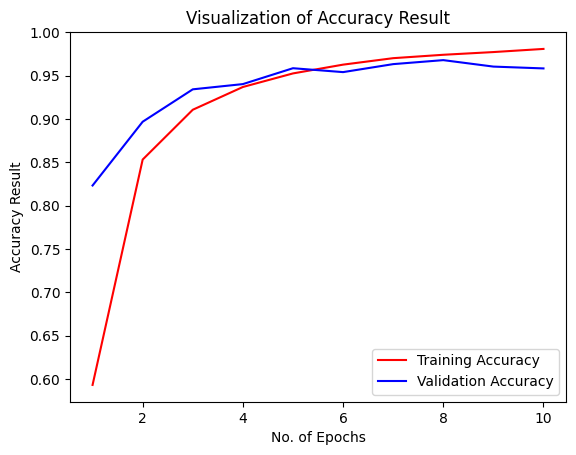

In [38]:
epochs = [i for i in range(1,11)]
plt.plot(epochs,training_history.history['accuracy'],color='red',label='Training Accuracy')
plt.plot(epochs,training_history.history['val_accuracy'],color='blue',label='Validation Accuracy')
plt.xlabel("No. of Epochs")
plt.ylabel("Accuracy Result")
plt.title("Visualization of Accuracy Result")
plt.legend()
plt.show()

# Some other metrics for model evaluation

In [39]:
class_name = validation_set.class_names
class_name

['Apple___Apple_scab',
 'Apple___Black_rot',
 'Apple___Cedar_apple_rust',
 'Apple___healthy',
 'Blueberry___healthy',
 'Cherry_(including_sour)___Powdery_mildew',
 'Cherry_(including_sour)___healthy',
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
 'Corn_(maize)___Common_rust_',
 'Corn_(maize)___Northern_Leaf_Blight',
 'Corn_(maize)___healthy',
 'Grape___Black_rot',
 'Grape___Esca_(Black_Measles)',
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 'Grape___healthy',
 'Orange___Haunglongbing_(Citrus_greening)',
 'Peach___Bacterial_spot',
 'Peach___healthy',
 'Pepper,_bell___Bacterial_spot',
 'Pepper,_bell___healthy',
 'Potato___Early_blight',
 'Potato___Late_blight',
 'Potato___healthy',
 'Raspberry___healthy',
 'Soybean___healthy',
 'Squash___Powdery_mildew',
 'Strawberry___Leaf_scorch',
 'Strawberry___healthy',
 'Tomato___Bacterial_spot',
 'Tomato___Early_blight',
 'Tomato___Late_blight',
 'Tomato___Leaf_Mold',
 'Tomato___Septoria_leaf_spot',
 'Tomato___Spider_mites Two-spotted_

In [40]:
test_set = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=False,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
)

Found 17572 files belonging to 38 classes.


In [41]:
y_pred = model.predict(test_set)
y_pred,y_pred.shape

550/550 ━━━━━━━━━━━━━━━━━━━━ 17s 30ms/step


(array([[9.9998868e-01, 2.6947635e-07, 2.4604265e-09, ..., 1.3796851e-12,
         6.5204537e-13, 7.4728078e-11],
        [9.9811763e-01, 1.2862997e-05, 3.9998227e-07, ..., 1.2586613e-09,
         2.6486047e-09, 2.9186781e-08],
        [9.9999964e-01, 1.5827156e-08, 8.3417406e-09, ..., 1.2565087e-13,
         3.2353846e-12, 3.3218880e-10],
        ...,
        [1.4995825e-05, 1.6271939e-06, 1.3481823e-04, ..., 1.6284453e-06,
         8.9891580e-07, 9.8443049e-01],
        [2.6925552e-06, 5.3350533e-08, 9.8455712e-07, ..., 1.7070151e-07,
         4.3859345e-08, 9.9984920e-01],
        [5.4080417e-19, 1.5872379e-20, 1.2952541e-19, ..., 1.8084194e-22,
         5.1032415e-21, 1.0000000e+00]], dtype=float32),
 (17572, 38))

In [42]:
predicted_categories = tf.argmax(y_pred,axis=1)

In [43]:
predicted_categories

<tf.Tensor: shape=(17572,), dtype=int64, numpy=array([ 0,  0,  0, ..., 37, 37, 37])>

In [44]:
true_categories = tf.concat([y for x,y in test_set],axis=0)
true_categories

<tf.Tensor: shape=(17572, 38), dtype=float32, numpy=
array([[1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.]], dtype=float32)>

In [45]:
Y_true = tf.argmax(true_categories,axis=1)
Y_true

<tf.Tensor: shape=(17572,), dtype=int64, numpy=array([ 0,  0,  0, ..., 37, 37, 37])>

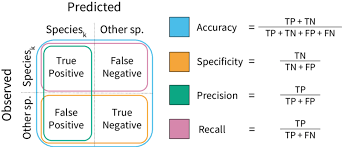)

In [46]:
from sklearn.metrics import classification_report,confusion_matrix

In [47]:
print(classification_report(Y_true,predicted_categories,target_names=class_name))

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.97      0.88      0.92       504
                                 Apple___Black_rot       0.96      0.99      0.98       497
                          Apple___Cedar_apple_rust       0.99      0.92      0.95       440
                                   Apple___healthy       0.89      0.98      0.94       502
                               Blueberry___healthy       0.98      0.97      0.97       454
          Cherry_(including_sour)___Powdery_mildew       1.00      0.96      0.98       421
                 Cherry_(including_sour)___healthy       0.95      1.00      0.97       456
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.93      0.95      0.94       410
                       Corn_(maize)___Common_rust_       0.98      1.00      0.99       477
               Corn_(maize)___Northern_Leaf_Blight       0.96      0.94      0.

In [48]:
cm = confusion_matrix(Y_true,predicted_categories)
cm

array([[442,   9,   0, ...,   0,   0,   0],
       [  0, 494,   0, ...,   0,   0,   0],
       [  0,   0, 403, ...,   0,   1,   3],
       ...,
       [  0,   0,   0, ..., 478,   0,   0],
       [  0,   0,   0, ...,   0, 444,   0],
       [  3,   0,   0, ...,   0,   0, 475]])

# Confusion Matrix Visualization

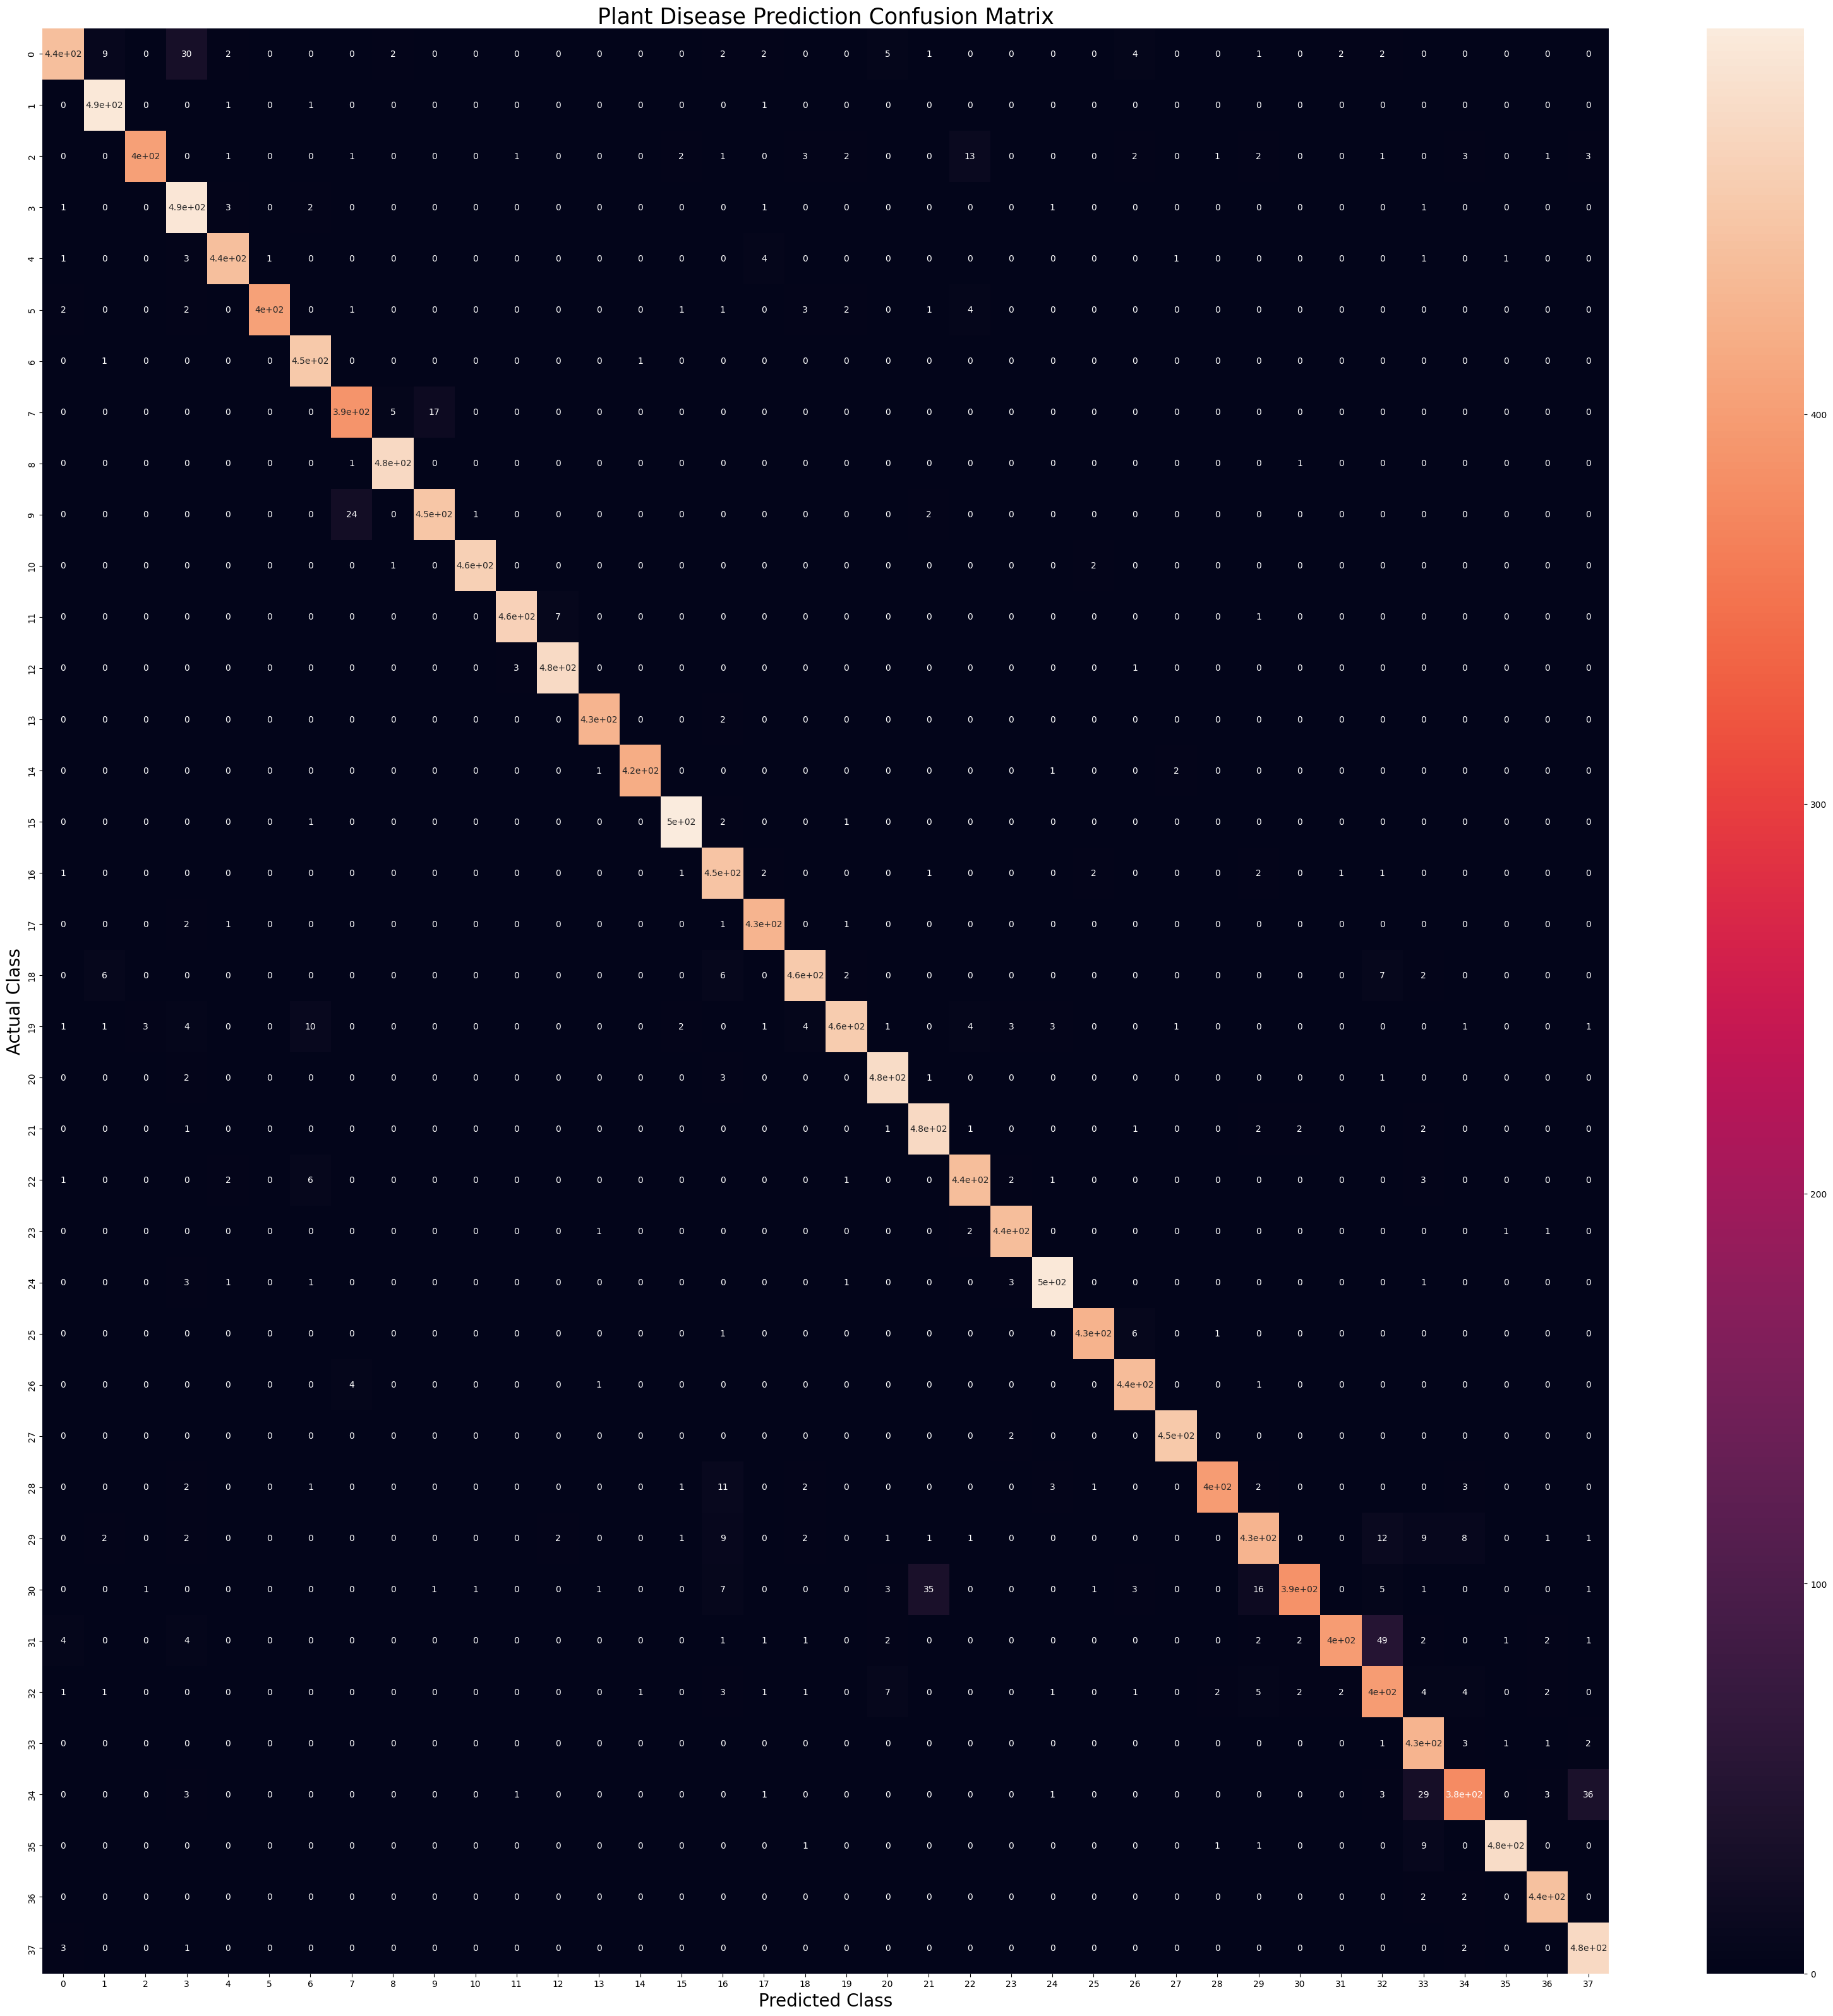

In [49]:
plt.figure(figsize=(40,40))
sns.heatmap(cm,annot=True,annot_kws={'size':10})
plt.xlabel("Predicted Class",fontsize=20)
plt.ylabel("Actual Class",fontsize=20)
plt.title("Plant Disease Prediction Confusion Matrix",fontsize=25)
plt.show()